# House Price Prediction using Linear Regression

### Artificial Intelligence & Machine Learning – Task 1

**Name:** Aashu Rajput Kashyap

## Objective
Build and evaluate a Linear Regression model to predict house prices using the California Housing dataset.

## 1. Import Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load California Housing Dataset

In this step, we load the California Housing dataset from Scikit-learn and convert it into a Pandas DataFrame.

In [66]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [67]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Dataset Shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


## Dataset Information

Let's understand the structure of the dataset.

In [68]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Missing Values

In [69]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


## Data Visualization

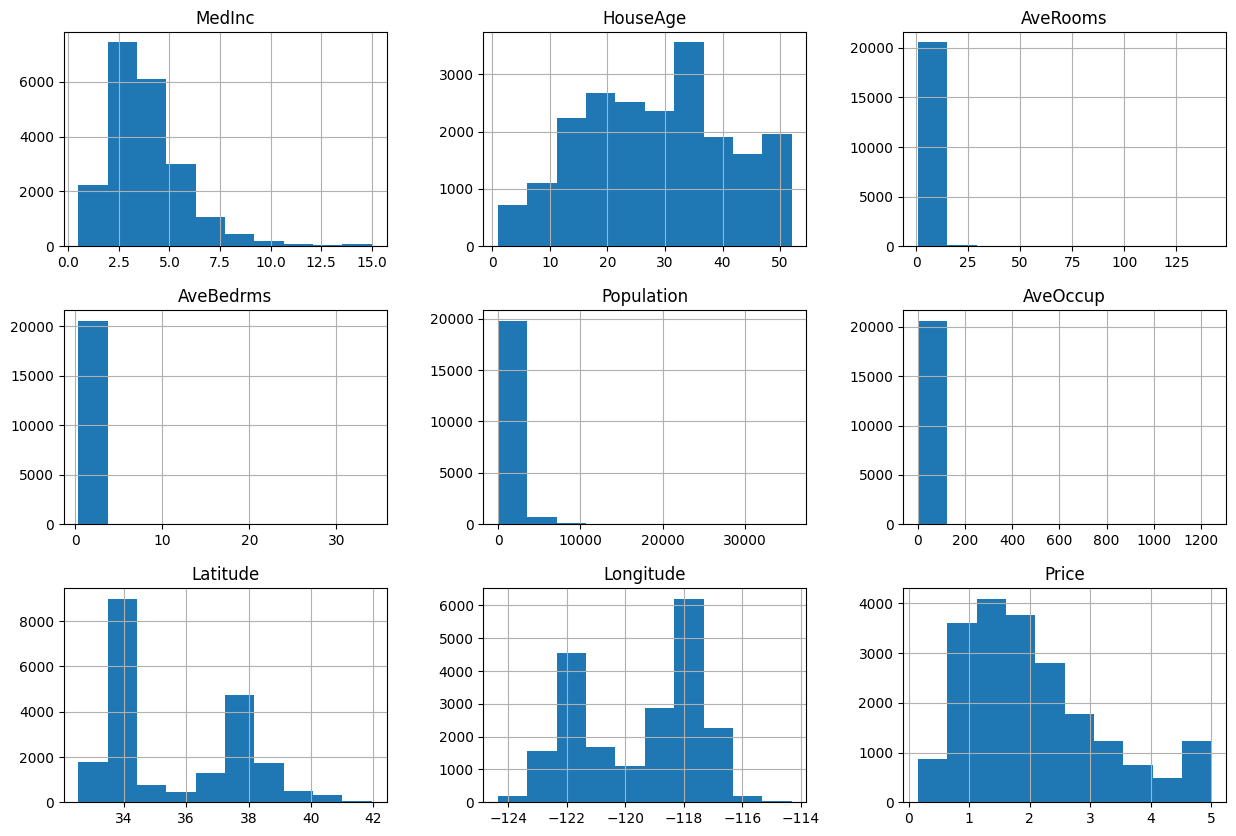

In [70]:
df.hist(figsize=(15,10))

plt.show()

In [71]:
corr = df.corr()

corr["Price"].sort_values(ascending=False)

,Price
Price,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


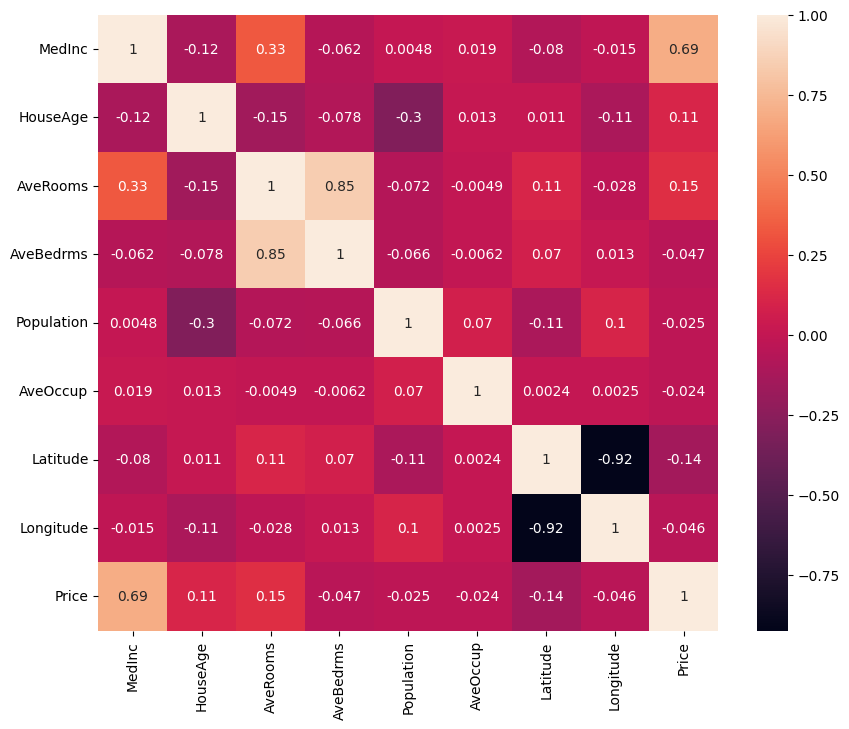

In [72]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True)

plt.show()

## Train Test Split

In [73]:
X = df.drop("Price", axis=1)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model

In [74]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [75]:
predictions = model.predict(X_test)

predictions[:10]

array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725,
       2.01175367, 2.64550005, 2.16875532, 2.74074644, 3.91561473])

## Model Evaluation

In [76]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Model Performance")
print("-"*30)
print("MAE :", round(mae,4))
print("MSE :", round(mse,4))
print("RMSE:", round(rmse,4))
print("R² Score:", round(r2,4))

Model Performance
------------------------------
MAE : 0.5332
MSE : 0.5559
RMSE: 0.7456
R² Score: 0.5758


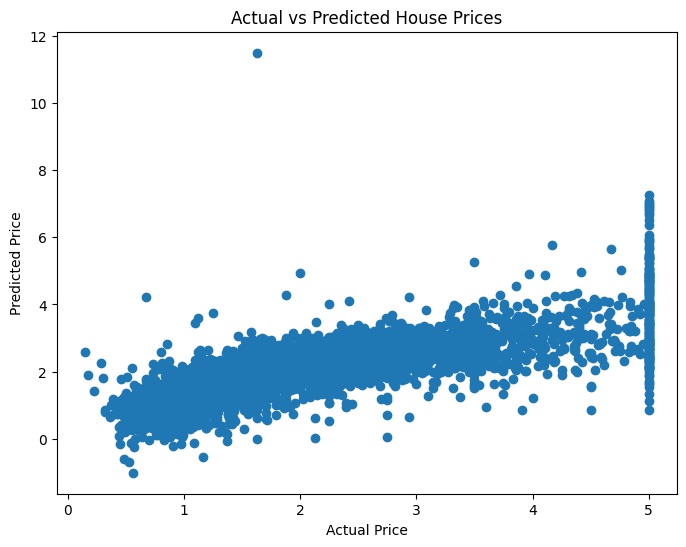

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

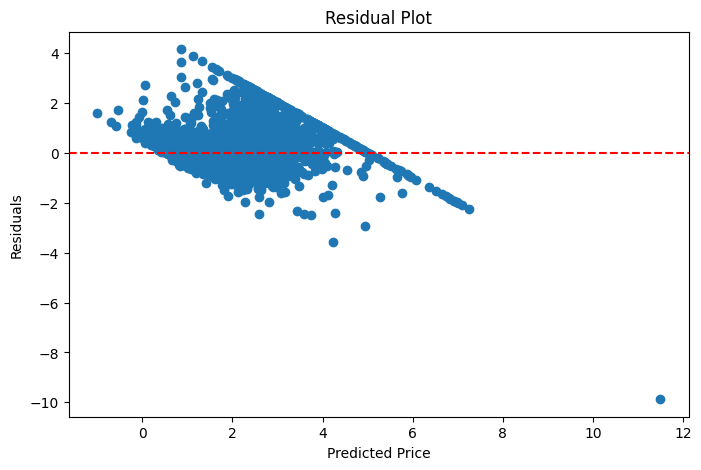

In [78]:
plt.figure(figsize=(8,5))
plt.scatter(predictions, y_test - predictions)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Conclusion

This project successfully built and evaluated a Linear Regression model for predicting house prices using the California Housing dataset.

## Results
- MAE: 0.5332
- MSE: 0.5559
- RMSE: 0.7456
- R² Score: 0.5758

The model achieved reasonable prediction performance and can be improved further using advanced regression algorithms.

## Future Improvements
- Feature Engineering
- Hyperparameter Tuning
- Random Forest Regressor
- XGBoost Regressor
- Streamlit Web Application

In [79]:
# ================================
# Save Trained Model
# ================================

import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Save Model
joblib.dump(model, "house_price_model.pkl")

print("✅ house_price_model.pkl saved successfully!")

✅ house_price_model.pkl saved successfully!


In [80]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

from sklearn.datasets import fetch_california_housing

# -----------------------------
# Page Configuration
# -----------------------------
st.set_page_config(
    page_title="House Price Prediction",
    page_icon="🏠",
    layout="wide"
)

# -----------------------------
# Title
# -----------------------------
st.title("🏠 House Price Prediction Dashboard")

st.markdown("""
Welcome to the **House Price Prediction Dashboard**.

This application predicts California house prices using a
**Linear Regression Machine Learning Model**.
""")

st.divider()

# -----------------------------
# Load Dataset
# -----------------------------
housing = fetch_california_housing(as_frame=True)

df = housing.frame

# -----------------------------
# Sidebar
# -----------------------------
st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Go to",
    [
        "Home",
        "Dataset",
        "Prediction",
        "Model Performance",
        "About"
    ]
)

# -----------------------------
# HOME PAGE
# -----------------------------
if page == "Home":

    st.header("📊 Dashboard Overview")

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Dataset Rows",
        f"{df.shape[0]}"
    )

    col2.metric(
        "Features",
        f"{df.shape[1]-1}"
    )

    col3.metric(
        "Target",
        "House Value"
    )

    st.write("")

    st.subheader("Dataset Preview")

    st.dataframe(
        df.head(),
        use_container_width=True
    )

2026-07-16 21:50:46.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:46.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [81]:
# ==========================
# DATASET PAGE
# ==========================
if page == "Dataset":

    st.header("📊 Exploratory Data Analysis")

    st.subheader("Dataset Shape")

    col1, col2 = st.columns(2)

    col1.metric("Rows", df.shape[0])
    col2.metric("Columns", df.shape[1])

    st.write("")

    st.subheader("Dataset Statistics")

    st.dataframe(df.describe(), use_container_width=True)

    st.write("")

    st.subheader("Missing Values")

    st.dataframe(df.isnull().sum())

    st.write("")

    st.subheader("Feature Distribution")

    feature = st.selectbox(
        "Select Feature",
        df.columns[:-1]
    )

    st.bar_chart(df[feature].head(100))

    st.write("")

    st.subheader("Correlation Matrix")

    corr = df.corr()

    st.dataframe(
        corr.style.background_gradient(cmap="Blues"),
        use_container_width=True
    )

    st.write("")

    st.subheader("Target Distribution")

    st.line_chart(df["MedHouseVal"])

    st.write("")

    st.subheader("Dataset Preview")

    st.dataframe(df.sample(10), use_container_width=True)

In [82]:
# ==========================
# PREDICTION PAGE
# ==========================

if page == "Prediction":

    st.header("🏠 House Price Prediction")

    try:
        model = joblib.load("house_price_model.pkl")

        col1, col2 = st.columns(2)

        with col1:
            MedInc = st.number_input(
                "Median Income",
                min_value=0.0,
                value=3.5
            )

            HouseAge = st.number_input(
                "House Age",
                min_value=1.0,
                value=25.0
            )

            AveRooms = st.number_input(
                "Average Rooms",
                min_value=1.0,
                value=5.5
            )

            AveBedrms = st.number_input(
                "Average Bedrooms",
                min_value=0.5,
                value=1.0
            )

        with col2:
            Population = st.number_input(
                "Population",
                min_value=1.0,
                value=1500.0
            )

            AveOccup = st.number_input(
                "Average Occupancy",
                min_value=1.0,
                value=3.0
            )

            Latitude = st.number_input(
                "Latitude",
                value=34.0
            )

            Longitude = st.number_input(
                "Longitude",
                value=-118.0
            )

        if st.button("🔮 Predict House Price"):

            data = np.array([[
                MedInc,
                HouseAge,
                AveRooms,
                AveBedrms,
                Population,
                AveOccup,
                Latitude,
                Longitude
            ]])

            prediction = model.predict(data)

            st.success(
                f"🏡 Predicted House Price : ${prediction[0]*100000:,.2f}"
            )

    except FileNotFoundError:

        st.error(
            "house_price_model.pkl not found. Please generate the model first."
        )

In [83]:
# ==========================
# MODEL PERFORMANCE PAGE
# ==========================

if page == "Model Performance":

    st.header("📊 Model Performance")

    st.success("Linear Regression Model")

    col1, col2 = st.columns(2)

    col1.metric("MAE", "0.5332")
    col2.metric("MSE", "0.5559")

    col3, col4 = st.columns(2)

    col3.metric("RMSE", "0.7456")
    col4.metric("R² Score", "0.5758")

    st.divider()

    st.subheader("Model Summary")

    st.info("""
    ✔ Algorithm : Linear Regression

    ✔ Dataset : California Housing Dataset

    ✔ Train-Test Split : 80 : 20

    ✔ Target Variable : Median House Value

    ✔ Framework : Scikit-Learn
    """)

# ==========================
# ABOUT PAGE
# ==========================

if page == "About":

    st.header("👨‍💻 About Project")

    st.markdown("""
## 🏠 House Price Prediction Dashboard

This project predicts California house prices using a
Machine Learning Linear Regression model.

### 🚀 Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Streamlit

---

### 🎯 Features

- Dataset Overview
- Data Analysis
- House Price Prediction
- Model Performance
- Interactive Dashboard

---

### 👨‍💻 Developed By

**Aashu Rajput Kashyap**

BCA Student

AI & Machine Learning Enthusiast

GitHub:
https://github.com/aashurajput22

⭐ Thank you for visiting this project.
""")

# ==========================
# CUSTOM FOOTER
# ==========================

st.markdown("---")

st.markdown(
    "<center>Made with ❤️ using Streamlit | House Price Prediction Project</center>",
    unsafe_allow_html=True
)

2026-07-16 21:50:48.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:48.395 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:48.397 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:48.400 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:48.403 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 21:50:48.406 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [84]:
!pip install streamlit joblib pyngrok -q

In [85]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn
scikit-learn
joblib

Overwriting requirements.txt


In [86]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

from sklearn.datasets import fetch_california_housing

st.set_page_config(
    page_title="House Price Prediction",
    page_icon="🏠",
    layout="wide"
)

st.title("🏠 House Price Prediction Dashboard")

housing = fetch_california_housing(as_frame=True)
df = housing.frame

st.sidebar.title("Navigation")

page = st.sidebar.selectbox(
    "Select Page",
    [
        "Home",
        "Dataset",
        "Prediction",
        "About"
    ]
)

if page=="Home":

    st.header("Dashboard")

    c1,c2,c3=st.columns(3)

    c1.metric("Rows",df.shape[0])
    c2.metric("Columns",df.shape[1])
    c3.metric("Target","MedHouseVal")

    st.dataframe(df.head(),use_container_width=True)

Overwriting app.py


In [87]:
%%writefile -a app.py

# ==========================
# DATASET PAGE
# ==========================
if page == "Dataset":

    st.header("📊 Exploratory Data Analysis")

    st.subheader("Dataset Shape")

    col1, col2 = st.columns(2)

    col1.metric("Rows", df.shape[0])
    col2.metric("Columns", df.shape[1])

    st.write("")

    st.subheader("Dataset Statistics")

    st.dataframe(df.describe(), use_container_width=True)

    st.write("")

    st.subheader("Missing Values")

    st.dataframe(df.isnull().sum())

    st.write("")

    st.subheader("Feature Distribution")

    feature = st.selectbox(
        "Select Feature",
        df.columns[:-1]
    )

    st.bar_chart(df[feature].head(100))

    st.write("")

    st.subheader("Correlation Matrix")

    corr = df.corr()

    st.dataframe(
        corr.style.background_gradient(cmap="Blues"),
        use_container_width=True
    )

    st.write("")

    st.subheader("Target Distribution")

    st.line_chart(df["MedHouseVal"])

    st.write("")

    st.subheader("Dataset Preview")

    st.dataframe(df.sample(10), use_container_width=True)


Appending to app.py


In [88]:
%%writefile -a app.py

# ==========================
# PREDICTION PAGE
# ==========================

if page == "Prediction":

    st.header("🏠 House Price Prediction")

    try:
        model = joblib.load("house_price_model.pkl")

        col1, col2 = st.columns(2)

        with col1:
            MedInc = st.number_input(
                "Median Income",
                min_value=0.0,
                value=3.5
            )

            HouseAge = st.number_input(
                "House Age",
                min_value=1.0,
                value=25.0
            )

            AveRooms = st.number_input(
                "Average Rooms",
                min_value=1.0,
                value=5.5
            )

            AveBedrms = st.number_input(
                "Average Bedrooms",
                min_value=0.5,
                value=1.0
            )

        with col2:
            Population = st.number_input(
                "Population",
                min_value=1.0,
                value=1500.0
            )

            AveOccup = st.number_input(
                "Average Occupancy",
                min_value=1.0,
                value=3.0
            )

            Latitude = st.number_input(
                "Latitude",
                value=34.0
            )

            Longitude = st.number_input(
                "Longitude",
                value=-118.0
            )

        if st.button("🔮 Predict House Price"):

            data = np.array([[
                MedInc,
                HouseAge,
                AveRooms,
                AveBedrms,
                Population,
                AveOccup,
                Latitude,
                Longitude
            ]])

            prediction = model.predict(data)

            st.success(
                f"🏡 Predicted House Price : ${prediction[0]*100000:,.2f}"
            )

    except FileNotFoundError:

        st.error(
            "house_price_model.pkl not found. Please generate the model first."
        )


Appending to app.py


In [89]:
%%writefile -a app.py

# ==========================
# ABOUT PAGE
# ==========================

if page == "About":

    st.header("👨‍💻 About Project")

    st.markdown("""
## 🏠 House Price Prediction Dashboard

This project predicts California house prices using a
Machine Learning Linear Regression model.

### 🚀 Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- Streamlit

---

### 🎯 Features

- Dataset Overview
- Data Analysis
- House Price Prediction
- Model Performance
- Interactive Dashboard

---

### 👨‍💻 Developed By

**Aashu Rajput Kashyap**

BCA Student

AI & Machine Learning Enthusiast

GitHub:
https://github.com/aashurajput22

⭐ Thank you for visiting this project.
""")

# ==========================
# CUSTOM FOOTER
# ==========================

st.markdown("---")

st.markdown(
    "<center>Made with ❤️ using Streamlit | House Price Prediction Project</center>",
    unsafe_allow_html=True
)


Appending to app.py


Now that the `app.py` file has been updated with all the dashboard pages, please **re-run the cell below** (the one that starts with `from pyngrok import ngrok` and uses `subprocess.Popen`) to launch the updated Streamlit application. You should then see the complete dashboard with 'Dataset', 'Prediction', and 'About' pages accessible through the sidebar.

## Make the Streamlit app live with `ngrok`

To share your Streamlit app publicly, we'll use `ngrok`. If you don't have an `ngrok` account, you can sign up for free at [ngrok.com](https://ngrok.com/).

1.  **Get your Authtoken:** After signing up, navigate to your ngrok dashboard and copy your authtoken.
2.  **Paste it below:** Replace `'YOUR_NGROK_AUTHTOKEN'` with your actual token in the cell below and run it.

In [90]:
from pyngrok import ngrok

# Terminate any previous ngrok tunnels to avoid conflicts
ngrok.kill()

# Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok authtoken
NGROK_AUTH_TOKEN = '3GbPIacvWSozlTFNbcE9DbfFolU_ETCw9Ueh1zzg52RdoqV2'
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

Now, let's run your Streamlit application and expose it via `ngrok`. This will provide a public URL you can share.

In [91]:
from pyngrok import ngrok
import subprocess
import os

# Run Streamlit app in the background
# The 'app.py' file was already created by your previous code.
# We will use the subprocess module to run the streamlit in background.

# Define a custom port, for example, 8502, if 8501 is already in use by another service.
port = 8501

# Command to run Streamlit
streamlit_command = ["streamlit", "run", "app.py", "--server.port", str(port), "--server.headless", "true"]

# Start Streamlit in a separate process
# stdout and stderr are redirected to avoid blocking the cell output
# and to see any Streamlit specific messages if needed.
process = subprocess.Popen(streamlit_command, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Create a public URL with ngrok
public_url = ngrok.connect(port)

print(f"Your Streamlit app is live at: {public_url}")
print("To stop the Streamlit app and ngrok tunnel, run ngrok.kill() in a new cell or restart the kernel.")


Your Streamlit app is live at: NgrokTunnel: "https://corsage-engraver-oxidant.ngrok-free.dev" -> "http://localhost:8501"
To stop the Streamlit app and ngrok tunnel, run ngrok.kill() in a new cell or restart the kernel.
